Compare repetition-centered lag-CRP curves for observed data and a matched control dataset.

Adjust `control_trial_query` to define alternative control populations.

Set `repetition_index` to 0 or 1 to focus on specific presentations.


In [1]:
# import jax
# jax.config.update("jax_disable_jit", True)
# jax.config.update("jax_debug_nans", True)

import matplotlib.pyplot as plt
import os

from jaxcmr.analyses.repcrp import (
    plot_rep_crp,
    subject_rep_crp,
    test_first_second_bias,
    test_rep_crp_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset
def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
# mixed_trial_query = "np.logical_and(data['list_type'] == 2, data['experiment'] > 0)"
# control_trial_query = "np.logical_and(data['list_type'] == 1, data['experiment'] > 0)"
# mixed_trial_query = "data['listLength'] > 0"
# control_trial_query = "data['listLength'] > 0"
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 5
size = 2


In [3]:
# Parameters
data_path = "projects/repfr/results/simulations/LohnasKahana2014_SimpleFullReinfPositionalCMRNoStop_rerun_best_of_1.h5"
figure_dir = "projects/repfr/results/figures/fitting"
figure_str = "LohnasKahana2014_SimpleFullReinfPositionalCMRNoStop_rerun_best_of_1_repcrp.png"
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 1
ylim = [0.05, 0.32]


In [4]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)
datasets = [data, control_dataset]
masks = [trial_mask, control_mask]


In [5]:
import jax.numpy as jnp
from jax import vmap
from jaxcmr.helpers import has_repeats_per_row
from jaxcmr.analyses import repcrp as repcrp_module

repeat_mask = has_repeats_per_row(control_dataset["recalls"])
print(f"control repeats: {int(jnp.sum(repeat_mask))} / {repeat_mask.size}")
print(
    "control max recall:",
    int(jnp.max(control_dataset["recalls"])),
    "max list length:",
    int(jnp.max(control_dataset["listLength"])),
)

actual, possible = vmap(repcrp_module.tabulate_trial, in_axes=(0, 0, None, None))(
    control_dataset["recalls"],
    control_dataset["pres_itemnos"],
    min_lag,
    size,
)
lag_range = control_dataset["pres_itemnos"].shape[1] - 1
lag0_idx = lag_range
print("control lag0 actual by rep index:", actual.sum(0)[:, lag0_idx])
print("control lag0 possible by rep index:", possible.sum(0)[:, lag0_idx])


control repeats: 0 / 168000
control max recall: 40 max list length: 40


control lag0 actual by rep index: 

[0 0]
control lag0 possible by rep index: [0 0]


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


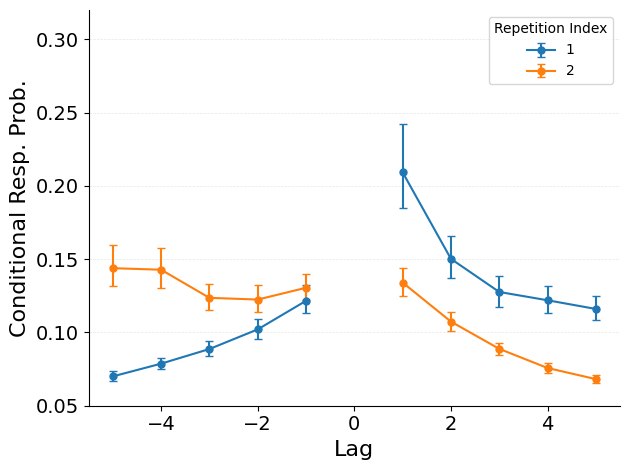

/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


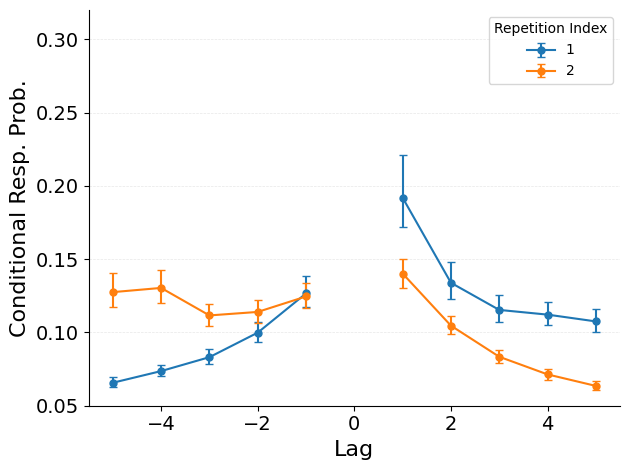

In [6]:
plot_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")
plot_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")


In [7]:
observed_crp = subject_rep_crp(data, trial_mask, min_lag, max_lag, size)
control_crp = subject_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print(f"\n{'='*60}")
    print(f"Statistical Tests: {label}")
    print(f"{'='*60}")
    print(result)


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    4.274     0.0001 |     98.0     0.0002 |     0.0043
   -4 |    5.476     0.0000 |     61.0     0.0000 |     0.0051
   -3 |    5.020     0.0000 |     69.0     0.0000 |     0.0056
   -2 |    1.766     0.0863 |    188.0     0.0371 |     0.0022
   -1 |   -2.114     0.0419 |    189.0     0.0387 |    -0.0050
    0 |      nan        nan |      nan        nan |        nan
    1 |    3.863     0.0005 |    120.0     0.0010 |     0.0173
    2 |    7.801     0.0000 |     13.0     0.0000 |     0.0163
    3 |    7.273     0.0000 |     29.0     0.0000 |     0.0123
    4 |    7.102     0.0000 |     34.0     0.0000 |     0.0098
    5 |    4.807     0.0000 |     77.0     0.0000 |     0.0085

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+------

/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:507: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:518: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)


In [8]:
bias_result = test_first_second_bias(observed_crp, control_crp, max_lag)
print(f"\n{'='*70}")
print("Test: First-Second Bias (Observed) vs First-Second Bias (Control)")
print(f"{'='*70}")
print("H0: The preference for first-presentation neighbors over second-presentation")
print("    neighbors is the same in observed data as in the shuffled control.")
print()
print(bias_result)


Test: First-Second Bias (Observed) vs First-Second Bias (Control)
H0: The preference for first-presentation neighbors over second-presentation
    neighbors is the same in observed data as in the shuffled control.

  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |   -4.853     0.0000 |     75.0     0.0000 |    -0.0120
   -4 |   -3.029     0.0047 |    141.0     0.0036 |    -0.0074
   -3 |   -3.904     0.0004 |    111.0     0.0005 |    -0.0064
   -2 |   -4.222     0.0002 |    104.0     0.0003 |    -0.0062
   -1 |   -4.824     0.0000 |     70.0     0.0000 |    -0.0110
    0 |      nan        nan |      nan        nan |        nan
    1 |    5.540     0.0000 |     52.0     0.0000 |     0.0235
    2 |    6.841     0.0000 |     16.0     0.0000 |     0.0136
    3 |    4.740     0.0000 |     75.0     0.0000 |     0.0068
    4 |    3.873     0.0005 |     83.0     0.0001 |     0.0054
    5 |    2.092     0.04

/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:576: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_d, ctrl_d, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/repcrp.py:587: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff_of_diff)
